<a href="https://colab.research.google.com/github/RafayRizwan023/Deep_Learning_Labs_Raf023/blob/main/Lab_05_Using_Simple_Model_with_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import torch
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


In [58]:
batch_size = 64
epochs = 20
lr = 0.01
momentum = 0.9

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [59]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)


testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,  shuffle=False, num_workers=2)


In [60]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=momentum)


In [61]:
# got the working from pytorch documentation on how to train the model itsel
# only used AI to wirte the code for visulization and getting the accuracy written more clearly

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # train
    net.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    # validation process
    net.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch [{epoch + 1}/{epochs}] '
          f'train loss: {train_loss:.3f}, train acc: {train_acc:.2f}% | '
          f'val loss: {val_loss:.3f}, val acc: {val_acc:.2f}%')

print('Finished Training')


Epoch [1/20] train loss: 1.884, train acc: 30.08% | val loss: 1.501, val acc: 44.80%
Epoch [2/20] train loss: 1.425, train acc: 48.14% | val loss: 1.427, val acc: 48.05%
Epoch [3/20] train loss: 1.257, train acc: 55.06% | val loss: 1.231, val acc: 56.37%
Epoch [4/20] train loss: 1.136, train acc: 59.99% | val loss: 1.192, val acc: 58.05%
Epoch [5/20] train loss: 1.056, train acc: 62.85% | val loss: 1.132, val acc: 60.61%
Epoch [6/20] train loss: 0.987, train acc: 65.18% | val loss: 1.094, val acc: 62.57%
Epoch [7/20] train loss: 0.924, train acc: 67.60% | val loss: 1.071, val acc: 63.36%
Epoch [8/20] train loss: 0.880, train acc: 68.97% | val loss: 1.050, val acc: 63.85%
Epoch [9/20] train loss: 0.842, train acc: 70.53% | val loss: 1.039, val acc: 63.87%
Epoch [10/20] train loss: 0.804, train acc: 71.76% | val loss: 1.066, val acc: 64.19%
Epoch [11/20] train loss: 0.763, train acc: 73.20% | val loss: 1.068, val acc: 64.18%
Epoch [12/20] train loss: 0.741, train acc: 73.90% | val loss: 

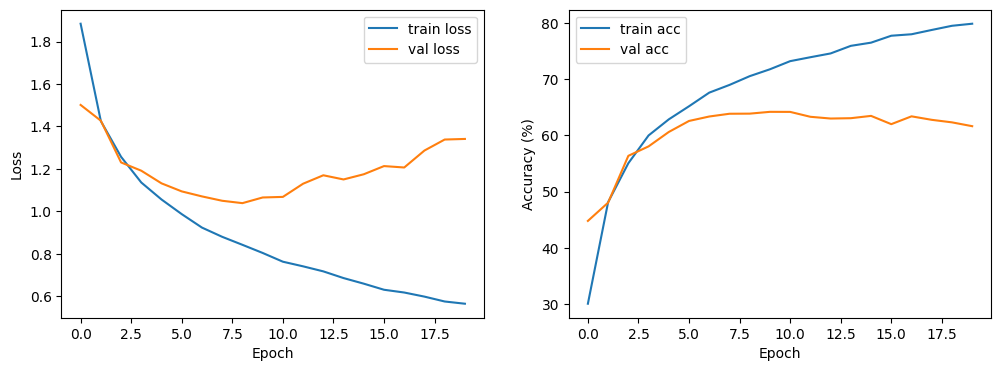

In [62]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='train acc')
plt.plot(val_accs, label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()


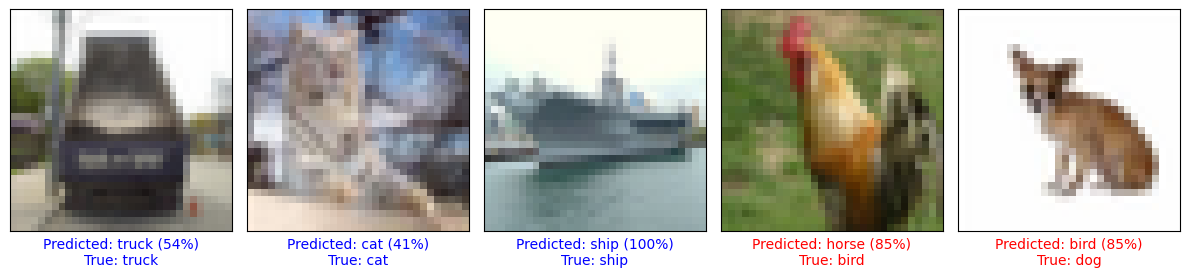

In [72]:
class_names = ['plane', 'car', 'bird', 'cat',
               'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

  # 5 random test indices (different every run)

net.eval()
idx = torch.randperm(len(testset))[:5]
test_images = torch.stack([testset[i][0] for i in idx])
test_labels = torch.tensor([testset[i][1] for i in idx])

with torch.no_grad():
    outputs = net(test_images.to(device))
    predictions = F.softmax(outputs, dim=1).cpu()     # probabilities, shape (5, 10)


# ---------------- Step 10: visualize predictions ----------------
def plot_image(i, predictions_array, true_label, img, class_names):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    img = img * 0.5 + 0.5                            # undo Normalize(0.5, 0.5)
    plt.imshow(img.permute(1, 2, 0).numpy())         # Ued fo the convertion

    predicted_label = predictions_array.argmax().item()
    color = 'blue' if predicted_label == true_label.item() else 'red'

    plt.xlabel(f"Predicted: {class_names[predicted_label]} "
               f"({100 * predictions_array.max():.0f}%)\n"
               f"True: {class_names[true_label.item()]}",
               color=color)


plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plot_image(i, predictions, test_labels, test_images, class_names)
plt.tight_layout()
plt.show()
